In [28]:
import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import jax.numpy as jnp
import jax
import numpy as np
import time
import datetime

In [ ]:
def generate_mixture_simulated_data(n_units=300, n_obs=50, n_components=2, seed=42):
    """Generates synthetic HMNL data drawn from a mixture of normals."""
    np.random.seed(seed)
    n_alts = 4
    n_params = 4  
    n_demos = 2   
    
    # Generate Demographic Data (Z) - NO INTERCEPT
    raw_demo_1 = np.random.normal(0, 1, n_units)
    raw_demo_2 = np.random.uniform(20, 60, n_units) 
    
    # Explicitly mean-center the demographic variables
    centered_demo_1 = raw_demo_1 - np.mean(raw_demo_1)
    centered_demo_2 = raw_demo_2 - np.mean(raw_demo_2)
    
    Z = np.column_stack([centered_demo_1, centered_demo_2])
    
    # TRUE Global Parameters (Delta) - Demographic shifts only
    Delta_true = np.array([
        [ 0.8, -0.3,  0.0,  0.5],  
        [-0.1,  0.2, -0.1, -0.2]   
    ])
    
    # TRUE Mixture Parameters
    true_pvec = np.array([0.6, 0.4]) 
    
    true_mu_k = np.array([
        [ 2.0, -1.0, -1.0, -3.0], # Segment 1 baseline
        [-1.0, -1.0,  3.0, -0.5]  # Segment 2 baseline
    ])
    
    true_Sigma_k = np.array([
        np.diag([0.5, 0.5, 0.5, 0.2]), 
        np.diag([1.0, 1.0, 1.5, 0.8])  
    ])
    
    # Generate Individual-Level Parameters
    beta_true = np.zeros((n_units, n_params))
    true_indicators = np.random.choice(n_components, size=n_units, p=true_pvec)
    
    for i in range(n_units):
        k = true_indicators[i]
        mu_i = Z[i] @ Delta_true + true_mu_k[k]
        beta_true[i] = np.random.multivariate_normal(mu_i, true_Sigma_k[k])
        
    X_list, y_list, unit_idx_list = [], [], []
    
    for i in range(n_units):
        for t in range(n_obs):
            X_it = np.zeros((n_alts, n_params))
            X_it[1, 0] = 1.0
            X_it[2, 1] = 1.0
            X_it[3, 2] = 1.0
            X_it[:, 3] = np.random.uniform(1.0, 5.0, n_alts)
            
            U_it = X_it @ beta_true[i]
            probs = np.exp(U_it) / np.sum(np.exp(U_it))
            y_it = np.random.choice(n_alts, p=probs)
            
            X_list.append(X_it)
            y_list.append(y_it)      # <--- RESTORED
            unit_idx_list.append(i)  # <--- RESTORED
            
    # <--- RESTORED RETURN STATEMENT
    return {
        "X": jnp.array(X_list),
        "y": jnp.array(y_list),
        "Z": jnp.array(Z),
        "unit_idx": jnp.array(unit_idx_list),
        "n_units": n_units,
        "n_params": n_params,
        "n_demos": n_demos,
        "K": n_components,
        "TRUE_DELTA": Delta_true,
        "TRUE_BETA": beta_true,
        "TRUE_PVEC": true_pvec,
        "TRUE_MU_K": true_mu_k
    }

In [30]:
# ============================
# 2. TFP HELPER DISTRIBUTIONS
# ============================

def make_wishart(df, scale_tril):
    return tfd.WishartTriL(df=df, scale_tril=scale_tril, input_output_cholesky=True, validate_args=False)

def make_mvn_precision(loc, precision_factor):
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

def make_beta_mixture(base_loc, mu, L, probs):
    n_units = base_loc.shape[0]
    K, n_params = mu.shape
    
    # Broadcast precision factors to match unit dimensions (n_units, K, n_params, n_params)
    L_broad = jnp.broadcast_to(L, (n_units, K, n_params, n_params))
    
    # Combine demographic base shift with component-specific means (n_units, K, n_params)
    combined_loc = base_loc[:, None, :] + mu[None, :, :]
    
    components_dist = tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=combined_loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(L_broad)
    )
    
    return tfd.MixtureSameFamily(
        mixture_distribution=tfd.Categorical(probs=probs),
        components_distribution=components_dist
    )

In [31]:
# ============================
# 3. LIESEL MODEL BUILDER
# ============================

def build_mixture_hmnl_model(data_dict, K=2, a_mu=0.01, dirichlet_alpha=5.0):
    n_params = int(data_dict["n_params"]) 
    n_units = int(data_dict["n_units"])
    n_demos = int(data_dict["n_demos"])

    # --- 1. Mixture Weights Prior (pvec ~ Dirichlet) ---
    pvec = lsl.Var.new_param(
        value=jnp.ones(K) / K,
        distribution=lsl.Dist(tfd.Dirichlet, concentration=jnp.ones(K) * dirichlet_alpha),
        name="pvec"
    )
    pvec_latent = pvec.transform(tfb.SoftmaxCentered(), name="pvec_latent")

    # --- 2. Covariance Priors (Sigma_k ~ IW) ---
    nu = float(n_params + 3)
    V_inv = jnp.linalg.inv(nu * jnp.eye(n_params))
    Vinv_chol = jnp.linalg.cholesky(V_inv)
    
    sigma_inv_chol = lsl.Var.new_param(
        value=jnp.stack([jnp.eye(n_params)] * K),
        distribution=lsl.Dist(make_wishart, df=nu, scale_tril=jnp.stack([Vinv_chol] * K)),
        name="sigma_inv_chol"
    )
    sigma_inv_chol_latent = sigma_inv_chol.transform(tfb.FillScaleTriL(), name="sigma_inv_chol_latent")

    # --- 3. Component Means Priors (mu_k ~ N(bar_mu, Sigma_k / a_mu)) ---
    bar_mu = jnp.zeros(n_params) # Prior grand mean
    
    mu_prec_factor = lsl.Var.new_calc(
        lambda L: jnp.sqrt(a_mu) * L, 
        L=sigma_inv_chol, 
        name="mu_prec_factor"
    )
    
    mu_k = lsl.Var.new_param(
        value=jnp.zeros((K, n_params)),
        distribution=lsl.Dist(
            make_mvn_precision, 
            loc=jnp.tile(bar_mu, (K, 1)), 
            precision_factor=mu_prec_factor
        ),
        name="mu_k"
    )

    # --- 4. Global Demographic Effects (vec(Delta) ~ N(bar_delta, A_delta^-1)) ---
    A_delta_precision = jnp.eye(n_demos * n_params) * 0.01 # Vague precision
    A_delta_chol = jnp.linalg.cholesky(A_delta_precision)
    bar_delta = jnp.zeros(n_demos * n_params)
    
    delta_vec = lsl.Var.new_param(
        value=jnp.zeros(n_demos * n_params),
        distribution=lsl.Dist(
            make_mvn_precision,
            loc=bar_delta,
            precision_factor=A_delta_chol
        ),
        name="delta_vec"
    )
    
    Delta = lsl.Var.new_calc(
        lambda d_vec: d_vec.reshape((n_demos, n_params)),
        d_vec=delta_vec,
        name="Delta"
    )
    
    Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
    base_loc = lsl.Var.new_calc(
        lambda z, delta: jnp.dot(z, delta), 
        z=Z_var, 
        delta=Delta, 
        name="base_loc"
    )

    # --- 5. Individual-Level Parameters (beta_i ~ MixtureSameFamily) ---
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params)),
        distribution=lsl.Dist(
            make_beta_mixture, 
            base_loc=base_loc, 
            mu=mu_k, 
            L=sigma_inv_chol, 
            probs=pvec
        ),
        name="beta_i"
    )

    # --- 6. Likelihood ---
    X_var = lsl.Var.new_obs(data_dict["X"], name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")
    
    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx], 
        b=beta_i, 
        idx=idx_var, 
        name="beta_expanded"
    )
    
    logits = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b), 
        x=X_var, 
        b=beta_expanded, 
        name="logits"
    )
    
    y_var = lsl.Var.new_obs(
        data_dict["y"], 
        distribution=lsl.Dist(tfd.Categorical, logits=logits), 
        name="y"
    )

    return lsl.Model([y_var])

In [32]:
# ============================
# 4. INFERENCE ENGINE
# ============================

def run_mixture_inference(model, chains=4, warmup=1000, posterior=2000, seed=123):
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)
    
    # Target latent parameters for NUTS
    eb.add_kernel(gs.NUTSKernel(["pvec_latent"]))
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel(["mu_k"])) 
    eb.add_kernel(gs.NUTSKernel(["delta_vec"])) # Target the vectorized version
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))
    
    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting NUTS Sampling...")
    engine = eb.build()
    engine.sample_all_epochs()
    
    return engine.get_results(), engine.get_results().get_posterior_samples()

In [33]:
# ============================
# 5. EXECUTION 
# ============================

print("Simulating data...")
# FIX: Change K=2 to n_components=2
choice_data = generate_mixture_simulated_data(n_components=2)

print("Building model...")
# The build model function correctly uses K
mixture_model = build_mixture_hmnl_model(choice_data, K=2)

start_time = time.time()
mcmc_results, posterior_samples = run_mixture_inference(
    mixture_model, 
    chains=2,       # Set to 2 or 4 depending on your hardware
    warmup=1000,     # Reduced for quick testing, increase for full run
    posterior=3000
)

formatted_time = str(datetime.timedelta(seconds=int(time.time() - start_time)))
print(f"Sampling finished in {formatted_time}")

Simulating data...
Building model...


liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:34<00:00, 11.40s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 4, 1 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 6, 4 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_03: 4, 5 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_04: 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 381.51chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain f

Sampling finished in 0:08:16


In [34]:
# 1. Reconstruct pvec from pvec_latent using the exact same TFP bijector
pvec_latent_samples = posterior_samples["pvec_latent"]
pvec_samples = tfb.SoftmaxCentered().forward(pvec_latent_samples)
recovered_pvec = np.mean(pvec_samples, axis=(0, 1))

# 2. Reconstruct Delta from delta_vec by reshaping the array
delta_vec_samples = posterior_samples["delta_vec"]
n_chains, n_draws, _ = delta_vec_samples.shape
n_demos = choice_data["n_demos"]
n_params = choice_data["n_params"]

# Reshape from (chains, draws, 8) -> (chains, draws, 2, 4)
Delta_samples = delta_vec_samples.reshape(n_chains, n_draws, n_demos, n_params)
recovered_Delta = np.mean(Delta_samples, axis=(0, 1))

# 3. Print the comparisons
print("\n--- Quick Parameter Check ---")
print("True Mixture Proportions: ", choice_data["TRUE_PVEC"])
print("Recovered Proportions:    ", np.round(recovered_pvec, 3))

print("\nTrue Delta:\n", choice_data["TRUE_DELTA"])
print("Recovered Delta:\n", np.round(recovered_Delta, 3))


--- Quick Parameter Check ---
True Mixture Proportions:  [0.6 0.4]
Recovered Proportions:     [0.5 0.5]

True Delta:
 [[ 0.8 -0.3  0.   0.5]
 [-0.1  0.2 -0.1 -0.2]]
Recovered Delta:
 [[ 0.83300006 -0.19800001  0.105       0.467     ]
 [-0.105       0.20600002 -0.10300001 -0.19900002]]


In [35]:
# Assuming you already reconstructed pvec_samples as we discussed previously:
pvec_latent_samples = posterior_samples["pvec_latent"]
pvec_samples = tfb.SoftmaxCentered().forward(pvec_latent_samples)

# Mean across DRAWS (axis=1), but keep CHAINS (axis=0) separate
chain_means = np.mean(pvec_samples, axis=1)

print("Pvec Mean for Chain 0:", np.round(chain_means[0], 3))
print("Pvec Mean for Chain 1:", np.round(chain_means[1], 3))

Pvec Mean for Chain 0: [0.35300002 0.647     ]
Pvec Mean for Chain 1: [0.647      0.35300002]


In [36]:
# 1. Get the indices that would sort pvec in descending order (largest component first)
# pvec_samples shape is (chains, draws, K)
sort_indices = np.argsort(-pvec_samples, axis=-1)

# 2. Align pvec using those indices
aligned_pvec = np.take_along_axis(pvec_samples, sort_indices, axis=-1)

# 3. Align mu_k using the exact same indices
# mu_k shape is (chains, draws, K, n_params)
mu_k_samples = posterior_samples["mu_k"]
n_params = mu_k_samples.shape[-1]

# Expand the indices to match the parameter dimension
expanded_indices = np.expand_dims(sort_indices, axis=-1)
expanded_indices = np.repeat(expanded_indices, n_params, axis=-1)

aligned_mu_k = np.take_along_axis(mu_k_samples, expanded_indices, axis=2) # axis=2 is the K dimension

# 4. Check the newly aligned results!
print("True Mixture Proportions: ", choice_data["TRUE_PVEC"])
print("ALIGNED Recovered pvec:   ", np.round(np.mean(aligned_pvec, axis=(0, 1)), 3))

print("\nTrue mu_k:\n", choice_data["TRUE_MU_K"])
print("ALIGNED Recovered mu_k:\n", np.round(np.mean(aligned_mu_k, axis=(0, 1)), 3))

True Mixture Proportions:  [0.6 0.4]
ALIGNED Recovered pvec:    [0.647      0.35300002]

True mu_k:
 [[ 2.  -1.  -1.  -3. ]
 [-1.  -1.   3.  -0.5]]
ALIGNED Recovered mu_k:
 [[ 2.0990002  -1.077      -0.90900004 -3.0240002 ]
 [-1.003      -1.014       3.0960002  -0.36100003]]


In [40]:
# ==========================================
# 0. ALIGN CHAINS (FIX LABEL SWITCHING)
# ==========================================
print("\n=== Aligning Chains to resolve Label Switching ===")

# Dynamically extract dimensions so it works for any number of chains/draws
n_chains, n_draws, _ = posterior_samples["delta_vec"].shape
K = choice_data["K"]
n_params = choice_data["n_params"]
n_demos = choice_data["n_demos"]

param_names = ["Brand 1", "Brand 2", "Brand 3", "Price"]
demo_names = ["Base (Intercept)", "Demographic 1"]

# 1. Reconstruct and Sort pvec
pvec_samples = tfb.SoftmaxCentered().forward(posterior_samples["pvec_latent"])
sort_indices = np.argsort(-pvec_samples, axis=-1)
aligned_pvec = np.take_along_axis(pvec_samples, sort_indices, axis=-1)

# 2. Align mu_k (Shape: chains, draws, K, params)
mu_k_samples = posterior_samples["mu_k"]
expanded_indices_mu = np.repeat(np.expand_dims(sort_indices, axis=-1), n_params, axis=-1)
aligned_mu_k = np.take_along_axis(mu_k_samples, expanded_indices_mu, axis=2)

# 3. Align sigma_inv_chol_latent (Shape: chains, draws, K, latent_dim)
latent_samples = posterior_samples["sigma_inv_chol_latent"]
n_latent = latent_samples.shape[-1]
expanded_indices_sigma = np.repeat(np.expand_dims(sort_indices, axis=-1), n_latent, axis=-1)
aligned_sigma_latent = np.take_along_axis(latent_samples, expanded_indices_sigma, axis=2)

# 4. Reshape Delta (Shape: chains, draws, demos, params) - No sorting needed, it is global
Delta_samples = posterior_samples["delta_vec"].reshape(n_chains, n_draws, n_demos, n_params)
print(f"Alignment complete for {n_chains} chains and {n_draws} draws.")


=== Aligning Chains to resolve Label Switching ===
Alignment complete for 2 chains and 3000 draws.



=== MCMC Convergence Summary (Cholesky Traces) ===

Plotting Cholesky Traces for Component 1...


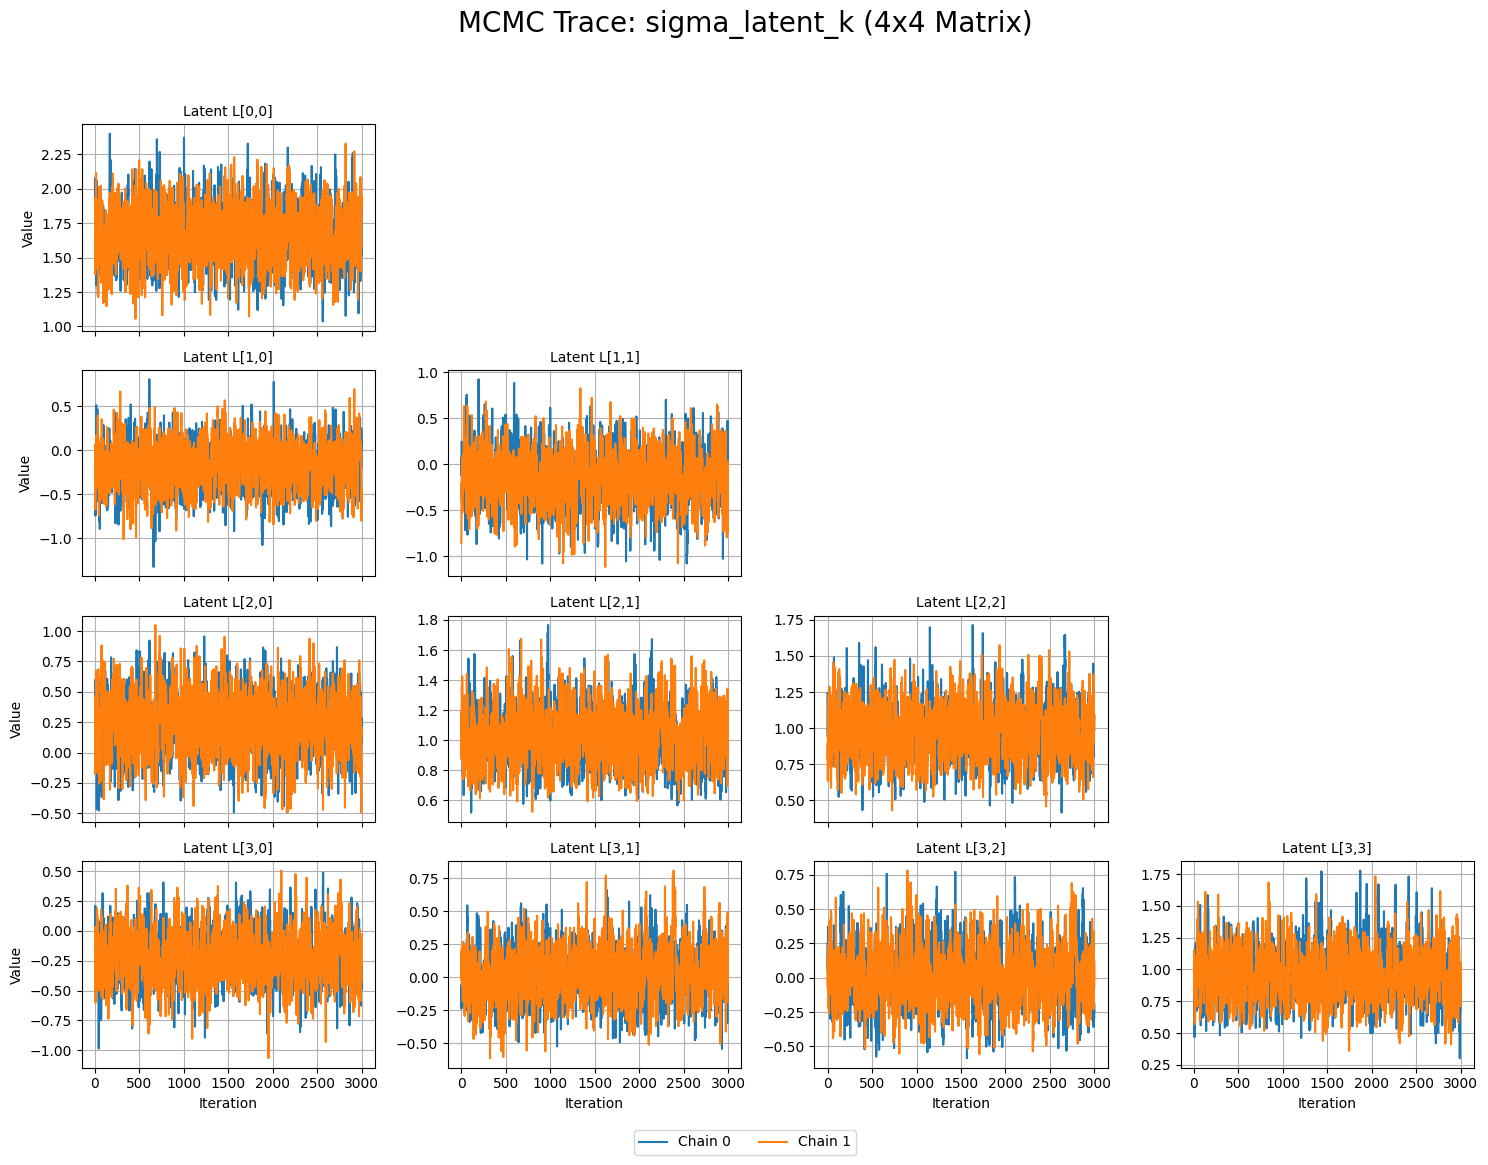


Plotting Cholesky Traces for Component 2...


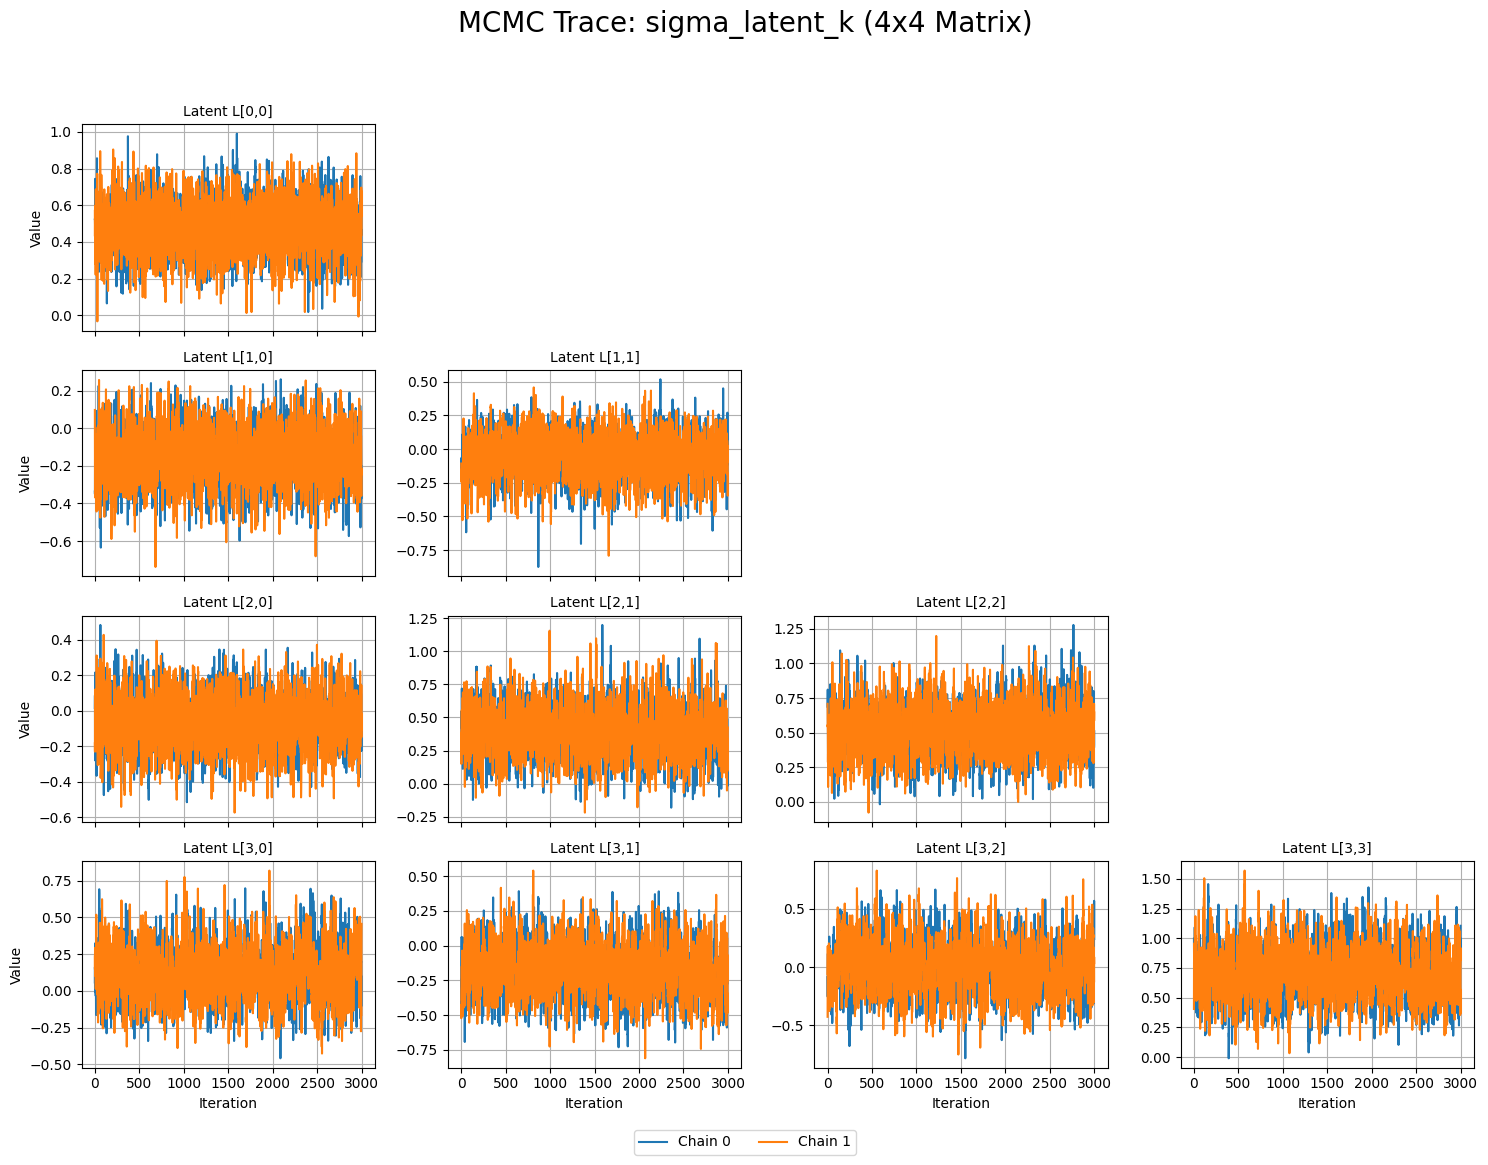

In [43]:
# ==========================================
# 1. MCMC DIAGNOSTICS & TRACE PLOTS
# ==========================================
print("\n=== MCMC Convergence Summary (Cholesky Traces) ===")
import matplotlib.pyplot as plt

# Using your exact function definition from before
def plot_cholesky_traces(samples_dict, n_params, param_name="sigma_inv_chol_latent", figsize=(15, 12)):
    """
    Plots MCMC trace plots for the latent parameters of a Cholesky factor matrix.
    
    This function dynamically generates a n_params x n_params grid, plotting the 
    MCMC chains for the lower triangular elements and hiding the upper triangular 
    axes where no parameters exist.

    Args:
        samples_dict (dict): A dictionary or similar data structure containing 
            the posterior samples.
        n_params (int): The dimensionality of the original square matrix.
        param_name (str, optional): The key in the samples dictionary corresponding 
            to the latent Cholesky parameters. Defaults to "sigma_inv_chol_latent".
        figsize (tuple, optional): The dimensions of the figure (width, height). 
            Defaults to (15, 12).

    Returns:
        tuple: A tuple containing the matplotlib Figure and a 2D array of Axes objects.
    """
    # Extract the latent samples
    latent_samples = samples_dict[param_name]
    n_chains, n_draws, n_latent = latent_samples.shape

    # Dynamically create grid based on n_params
    fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True, sharey=False)
    
    # Handle the edge case where n_params == 1 (axes is not a 2D array)
    if n_params == 1:
        axes = np.array([[axes]])

    # Counter to keep track of which latent parameter we are plotting
    latent_idx = 0

    for i in range(n_params):        # Rows
        for j in range(n_params):    # Columns
            ax = axes[i, j]
            
            # In a lower triangular matrix, parameters exist only where i >= j
            if i >= j and latent_idx < n_latent:
                for chain in range(n_chains):
                    ax.plot(
                        latent_samples[chain, :, latent_idx],
                        label=f"Chain {chain}"
                    )
                
                ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                latent_idx += 1
            else:
                # Hide axes for the upper triangle where there is no data
                ax.axis('off')
            
            # Grid and formatting
            ax.grid(True)
            
            # Only add x-labels to the bottom-most active subplots
            if i == n_params - 1 or (i >= j and i + 1 < n_params and i + 1 < j): 
                ax.set_xlabel("Iteration")
                
            # Only add y-labels to the first column
            if j == 0:
                ax.set_ylabel("Value")

    # Add a single legend for the whole figure
    # Extract handles from the first valid plot (0,0)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, 
        labels, 
        loc='lower center', 
        ncol=n_chains, 
        bbox_to_anchor=(0.5, 0.02)
    )

    plt.suptitle(
        f"MCMC Trace: {param_name} ({n_params}x{n_params} Matrix)", 
        fontsize=20
    )
    
    # Adjust layout to make room for the legend at the bottom and title at the top
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()
    
    return fig, axes

# We now loop over the K components
for k in range(K):
    print(f"\nPlotting Cholesky Traces for Component {k+1}...")
    # Package the aligned component data into a dictionary format the function expects
    comp_dict = {"sigma_latent_k": aligned_sigma_latent[:, :, k, :]}
    fig, axes = plot_cholesky_traces(
        samples_dict=comp_dict, 
        n_params=n_params,
        param_name="sigma_latent_k"
    )

In [44]:
# ==========================================
# 2. COVARIANCE RECOVERY & PLOTTING
# ==========================================
print("\nRecovering Covariance Matrices (Sigma_k)...")

bijector = tfb.FillScaleTriL()
def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

# Update vmap to handle the extra K dimension: vmap(chains) -> vmap(draws) -> vmap(K)
v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
sigma_samples_all = v_latent_to_sigma(aligned_sigma_latent) 

# Using your exact plot_final_covariance_complete function definition...
from matplotlib.lines import Line2D
print("\nRecovering Covariance Matrix (Sigma)...")

# Setup the bijector (must match the one in the model)
bijector = tfb.FillScaleTriL()

# Function to turn 1D vector -> Lower Triangular Matrix -> Covariance Matrix
def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

# Vectorize across chains and draws
v_latent_to_sigma = jax.vmap(jax.vmap(latent_to_sigma))

# Extract the latent samples from your previous Liesel run
latent_samples = posterior_samples["sigma_inv_chol_latent"]
sigma_samples = v_latent_to_sigma(latent_samples)

def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None):
    n_dim = samples.shape[-1]
    
    # Create the figure and axes
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    # Color Palette
    diag_color      = "#002347"  
    off_diag_color  = "#4682B4"  
    true_val_color  = "#D62728"  
    emp_val_color   = "#2CA02C"  

    # Loop through the grid
    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            
            # Lower Triangular Logic
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = flattened_samples[:, i, j]
            is_diag = (i == j)
            current_color = diag_color if is_diag else off_diag_color
            
            # Stats Calculation
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            # Plot KDE
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            # Reference Lines
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            
            if true_matrix is not None:
                true_val = true_matrix[i, j]
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_val:.2f}")
            
            if empirical_matrix is not None:
                emp_val = empirical_matrix[i, j]
                ax.axvline(emp_val, color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {emp_val:.2f}")

            # Textual Labels
            stats_str = " | ".join(title_parts)
            title_str = (
                f"{stats_str}\n"
                f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            )
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')

            # Aesthetic Polish
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    # --- NEW: FIGURE-LEVEL FLOATING LEGEND ---
    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval'),
        Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Parameter Value'),
        Line2D([0], [0], color=emp_val_color,  linestyle='-.', lw=2, label='Empirical Data Covariance')
    ]
    
    # We use fig.legend instead of ax.legend
    fig.legend(
        handles=legend_elements, 
        loc='upper right',           # Anchor point on the legend box
        bbox_to_anchor=(0.9, 0.9), # (x, y) coordinates for the anchor relative to the whole figure (0 to 1)
        fontsize=14, 
        frameon=True,        
        edgecolor='black',    
        framealpha=1,        
        fancybox=True        
    )

    plt.suptitle("Posterior distributions vs True & Empirical Covariance", 
                 fontsize=24, y=0.98, fontweight='light')
    
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

for k in range(K):
    print(f"\nCovariance Recovery for Component {k+1}")
    # Flatten chains and draws into a single dimension for the plot function
    sigma_k_flat = sigma_samples_all[:, :, k, :, :].reshape(-1, n_params, n_params)
    plot_final_covariance_complete(sigma_k_flat, choice_data["TRUE_SIGMA_K"][k], empirical_matrix=None)


Recovering Covariance Matrices (Sigma_k)...

Recovering Covariance Matrix (Sigma)...


ValueError: Incompatible shapes for matmul arguments: (2, 4, 4) and (4, 4, 2)